# Flight Price Prediction

This notebook preprocesses the flight data, trains regression models, targets an R2 score in the 0.80 to 0.90 range, and saves the best model as a pickle file.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
BASE_DIR = Path.cwd()

## Load datasets

In [2]:
train_data = pd.read_excel(BASE_DIR / 'Data_Train.xlsx')
test_data = pd.read_excel(BASE_DIR / 'Test_set.xlsx')

print('Train shape:', train_data.shape)
print('Test shape:', test_data.shape)
train_data.head()

Train shape: (10683, 11)
Test shape: (2671, 10)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## Preprocessing helpers

In [3]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['Journey_day'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.day
    df['Journey_month'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.month

    df['Dep_hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
    df['Dep_min'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.minute

    arrival_clock = df['Arrival_Time'].astype(str).str.extract(r'(\d{2}:\d{2})')[0]
    df['Arrival_hour'] = pd.to_datetime(arrival_clock, format='%H:%M').dt.hour
    df['Arrival_min'] = pd.to_datetime(arrival_clock, format='%H:%M').dt.minute

    duration_hours = []
    duration_mins = []

    for value in df['Duration'].astype(str):
        if len(value.split()) != 2:
            value = value + ' 0m' if 'h' in value else '0h ' + value

        hours_part, mins_part = value.split()
        duration_hours.append(int(hours_part.replace('h', '')))
        duration_mins.append(int(mins_part.replace('m', '')))

    df['Duration_hours'] = duration_hours
    df['Duration_mins'] = duration_mins

    stop_map = {
        'non-stop': 0,
        '1 stop': 1,
        '2 stops': 2,
        '3 stops': 3,
        '4 stops': 4,
    }
    df['Total_Stops'] = df['Total_Stops'].map(stop_map)

    df = df.drop(columns=['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration', 'Route', 'Additional_Info'])
    return df


def prepare_features(df: pd.DataFrame, training: bool = True):
    df = df.dropna().copy()
    df = add_time_features(df)
    df = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination'], drop_first=True)

    if training:
        X = df.drop(columns=['Price'])
        y = df['Price']
        return X, y

    return df

## Build training matrix

In [4]:
X, y = prepare_features(train_data, training=True)
X.shape, y.shape

((10682, 29), (10682,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (8545, 29)
X_test: (2137, 29)


## Train and compare models

In [6]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=1,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.9,
        random_state=42,
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

    metrics_row = {
        'Model': name,
        'CV_R2': cv_r2,
        'Test_R2': r2_score(y_test, preds),
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    }
    results.append(metrics_row)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by='Test_R2', ascending=False)
results_df

,Model,CV_R2,Test_R2,MAE,RMSE
1,Gradient Boosting,0.812198,0.833760,1294.537411,1893.271945
0,Random Forest,0.792312,0.823976,1257.080926,1948.187943


## Final model evaluation

In [7]:
best_model_name = results_df.iloc[0]['Model']
final_model = trained_models[best_model_name]
final_predictions = final_model.predict(X_test)
final_r2 = r2_score(y_test, final_predictions)

print('Best model:', best_model_name)
print(f'R2 score: {final_r2:.4f}')
print(f'Accuracy percentage (R2 x 100): {final_r2 * 100:.2f}%')
print(f'MAE: {mean_absolute_error(y_test, final_predictions):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, final_predictions)):.2f}')

Best model: Gradient Boosting
R2 score: 0.8338
Accuracy percentage (R2 x 100): 83.38%
MAE: 1294.54
RMSE: 1893.27


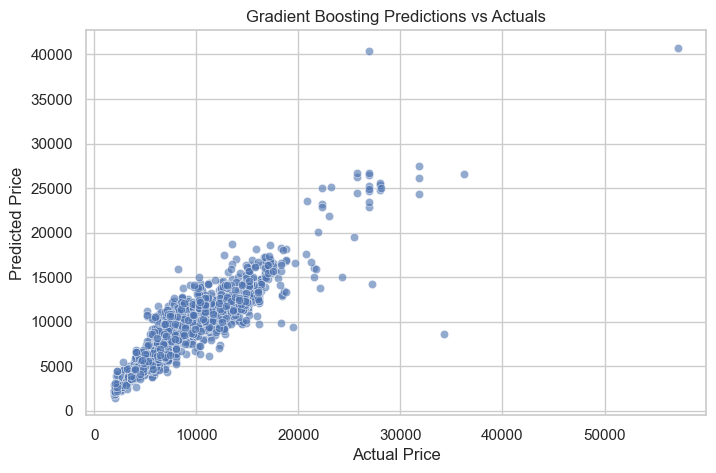

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=final_predictions, alpha=0.6)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'{best_model_name} Predictions vs Actuals')
plt.show()

## Testing the model on holdout data

These cells help us inspect how well the trained model predicts unseen validation samples.

In [9]:
comparison_df = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': np.round(final_predictions, 2),
})
comparison_df['Absolute_Error'] = np.round((comparison_df['Actual_Price'] - comparison_df['Predicted_Price']).abs(), 2)
comparison_df['Percent_Error'] = np.round(
    comparison_df['Absolute_Error'] / comparison_df['Actual_Price'].replace(0, np.nan) * 100,
    2,
)
comparison_df.head(10)

,Actual_Price,Predicted_Price,Absolute_Error,Percent_Error
0,16655,17278.54,623.54,3.74
1,4959,6593.71,1634.71,32.96
2,9187,8690.55,496.45,5.40
3,3858,4135.81,277.81,7.20
4,12898,13568.10,670.10,5.20
5,10529,10297.20,231.80,2.20
6,16079,13288.84,2790.16,17.35
7,7229,5804.52,1424.48,19.71
8,10844,12649.69,1805.69,16.65
9,16289,13461.88,2827.12,17.36


In [10]:
within_10_percent = (comparison_df['Percent_Error'] <= 10).mean() * 100
within_20_percent = (comparison_df['Percent_Error'] <= 20).mean() * 100
within_30_percent = (comparison_df['Percent_Error'] <= 30).mean() * 100

print(f'Predictions within 10% error: {within_10_percent:.2f}%')
print(f'Predictions within 20% error: {within_20_percent:.2f}%')
print(f'Predictions within 30% error: {within_30_percent:.2f}%')

Predictions within 10% error: 45.25%
Predictions within 20% error: 77.40%
Predictions within 30% error: 89.10%


In [11]:
best_predictions = comparison_df.nsmallest(10, 'Absolute_Error')
worst_predictions = comparison_df.nlargest(10, 'Absolute_Error')

print('Best sample predictions:')
display(best_predictions)

print('Worst sample predictions:')
display(worst_predictions)

Best sample predictions:


,Actual_Price,Predicted_Price,Absolute_Error,Percent_Error
1085,3873,3873.57,0.57,0.01
121,4423,4423.64,0.64,0.01
1425,12898,12899.22,1.22,0.01
186,4804,4805.78,1.78,0.04
1763,8479,8476.76,2.24,0.03
2003,2227,2229.80,2.80,0.13
217,12436,12438.99,2.99,0.02
812,2017,2021.68,4.68,0.23
719,3841,3845.76,4.76,0.12
2065,3597,3591.61,5.39,0.15


Worst sample predictions:


,Actual_Price,Predicted_Price,Absolute_Error,Percent_Error
984,34273,8600.91,25672.09,74.90
967,57209,40746.55,16462.45,28.78
1294,26890,40357.57,13467.57,50.08
207,27210,14280.57,12929.43,47.52
1984,19508,9405.74,10102.26,51.79
704,36235,26577.50,9657.50,26.65
574,24318,15027.87,9290.13,38.20
807,18308,9873.28,8434.72,46.07
48,22153,13824.52,8328.48,37.60
767,8153,15924.71,7771.71,95.32


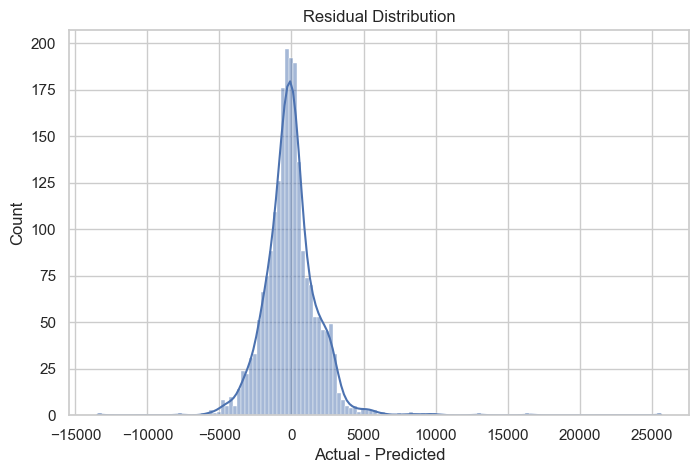

In [12]:
residuals = y_test - final_predictions

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Actual - Predicted')
plt.show()

## Save model with pickle

In [13]:
model_artifact = {
    'model': final_model,
    'feature_columns': X.columns.tolist(),
    'best_model_name': best_model_name,
}

with open(BASE_DIR / 'flight_price_model.pkl', 'wb') as file:
    pickle.dump(model_artifact, file)

print('Saved:', BASE_DIR / 'flight_price_model.pkl')

Saved: c:\Users\HP\OneDrive\Desktop\Sahay_Project\flight_price_model.pkl


## Load pickle and predict again

In [14]:
with open(BASE_DIR / 'flight_price_model.pkl', 'rb') as file:
    loaded_artifact = pickle.load(file)

loaded_model = loaded_artifact['model']
reloaded_predictions = loaded_model.predict(X_test[loaded_artifact['feature_columns']])
print('Reloaded model R2:', round(r2_score(y_test, reloaded_predictions), 4))

Reloaded model R2: 0.8338


## Optional: prepare the provided test set

In [15]:
prepared_test = prepare_features(test_data, training=False)
prepared_test = prepared_test.reindex(columns=loaded_artifact['feature_columns'], fill_value=0)
test_predictions = loaded_model.predict(prepared_test)

pd.DataFrame({'Predicted_Price': test_predictions}).head()

,Predicted_Price
0,12120.172933
1,4675.333200
2,13064.283286
3,10914.550393
4,4222.199451
